# Preparing Fine-Tuning Data and Understanding the Objective

**Hugging Face Models and Fine-Tuning · Lecture 2 · self-paced tutorial**  
**Estimated study time:** 60–90 minutes, excluding model downloads and optional large-model extensions  
**Typical code runtime:** 25–35 minutes

## Learning outcomes

- Convert conversation trees into isolated train and evaluation examples.
- Render chat templates and mask non-response labels.
- Explain what full fine-tuning updates and why its memory cost exceeds weight storage.

| Learning stage | What you will do |
|---|---|
| Orient | Read the driving question and prerequisite recap. |
| Build intuition | Work through the visual model and hand calculation. |
| Implement | Run the code in order and investigate the first failed check. |
| Consolidate | Complete the practice checkpoint and summarize the evidence. |

## Driving question

> **How do we turn branching conversations into labels without leakage or training on the user's words?**

Keep this question in mind as you work. Each calculation, figure, and
code cell gives you one more piece of the answer.

### Before you begin

Recall structured messages, chat templates, token IDs, shifted next-token loss, and the distinction between train and evaluation splits.

OpenAssistant stores trees rather than independent rows. Two candidate answers can share the same user request and ancestors. Randomly splitting extracted branches therefore leaks nearly identical context into evaluation. We will keep a stable tree identifier, assign whole trees to one split, select eligible branches only afterward, and retain source metadata through every transformation.

Fine-tuning code is often surprisingly short. Most of the intellectual work moves to the data: deciding what a good response looks like, preventing train–test leakage, masking the correct tokens, and checking whether the new behavior damages capabilities we meant to preserve.

## How this lesson builds, step by step


We begin with a result we can check by hand, make it reusable, and then
test something that could still be wrong even when the code runs:

1. **Inspect canonical messages.** Check who wrote each message and which conversation tree it came from before turning the messages into text. The checkpoint is useful only when the observed output supports this purpose.
2. **Prove tree-level isolation.** Use an assertion to confirm that no conversation tree appears in both training and evaluation. The checkpoint is useful only when the observed output supports this purpose.
3. **Construct response-only labels.** Make the exact supervised objective inspectable. The checkpoint is useful only when the observed output supports this purpose.
4. **Estimate full-tuning memory.** Establish the baseline that LoRA and quantization will improve. The checkpoint is useful only when the observed output supports this purpose.

If an early result differs from your prediction, stop there. Check its
structure, its numerical values, and its behavior on a small example.
A larger model only makes an early mistake harder to find.

## Reproducible setup

We will inspect the packaged OpenAssistant records and the real chat template used by the classroom model. The code uses only files inside this course folder plus the model tokenizer downloaded from Hugging Face.

In [ ]:
from pathlib import Path
import json, random, sys

COURSE_ROOT = next(
    candidate for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (candidate / "course_helpers.py").is_file()
)
if str(COURSE_ROOT) not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT))

SEED = 2026
random.seed(SEED)
print("Course folder:", COURSE_ROOT)

### Split conversation trees without sharing ancestors

Two branches can repeat the same earlier messages, so tree identity—not extracted row identity—must control the split.

**Check your understanding:** What information would leak if sibling branches appeared in training and evaluation?

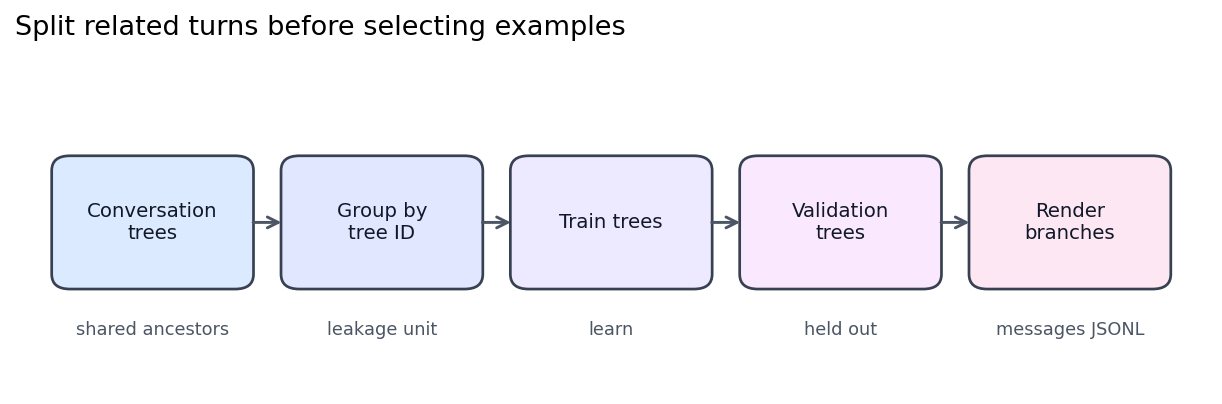

## Learn and test: Inspect canonical messages

Fine-tuning begins with data contracts, not a Trainer call. Group OpenAssistant branches by conversation tree before splitting, render structured messages with the pinned chat template, preserve assistant targets through truncation, and use response-only labels. Full tuning updates every base parameter; this lecture explains the objective without requiring a 1.5B-parameter full update.

## Turn conversation trees into isolated examples

OpenAssistant data contains branching conversation trees. Two branches may repeat the same prompt and ancestors, so randomly splitting rendered rows would place near-duplicates in training and evaluation. Group by tree identifier first, assign whole trees to one split, then select and render eligible English branches. Preserve stable source IDs so every transformed row can be traced back through the manifest.

### Work the smallest useful example

A canonical example remains a list of `{role, content}` messages until the pinned tokenizer renders control tokens. For response-only SFT, system, user, and non-target assistant tokens receive label `-100`; target assistant IDs remain active. If four prompt tokens and three answer tokens form the sequence, labels are `[-100,-100,-100,-100,a1,a2,a3]`. The active fraction exposes records whose useful answer was removed by truncation.

Keep this result visible. The code should reproduce the same relationship; if
it does not, locate the first value that differs before changing the model.

### Structured messages become one token sequence

The tokenizer's chat template inserts the role markers and separators used during instruction tuning.

**Check your understanding:** Why is a handwritten transcript not necessarily equivalent to `apply_chat_template`?

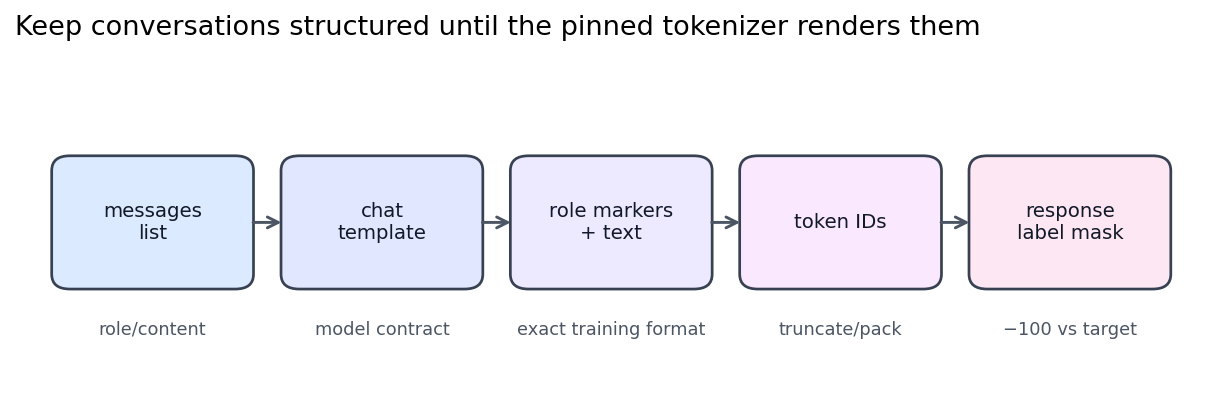

### Try it: Inspect canonical messages

**What this cell shows**

Check who wrote each message and which conversation tree it came from before turning the messages into text.

**What goes in and comes out**

- One record has a string tree ID and a list of role/content dictionaries.

**Follow the calculation**

1. Print structured JSON first
2. rendering is a derived representation, not the stored source of truth.

**Before you run the cell**

Which field must be used to group train/evaluation splits? Write down the expected value, shape, or ordering before running the cell.

In [ ]:
from course_helpers import read_jsonl

train_path = COURSE_ROOT / "data" / "classroom" / "sft_train.jsonl"
eval_path = COURSE_ROOT / "data" / "evaluation" / "sft_evaluation.jsonl"
train_rows = read_jsonl(train_path)
eval_rows = read_jsonl(eval_path)
conversation = train_rows[0]

print("record:", conversation["id"])
print("tree:", conversation["source_tree_id"])
print("roles:", [message["role"] for message in conversation["messages"]])
print("final answer preview:", conversation["messages"][-1]["content"][:160])

**What you should see**

The tree ID captures shared ancestry that row-level random splits miss.

**If your result looks different**

Flattening to plain text too early loses role boundaries and reliable masking.

Before moving on, compare the output with your prediction. If they differ, use the data description and tensor shapes above to find the first unexpected step.

## Learn and test: Prove tree-level isolation

Store the canonical record as structured `messages`. The pinned tokenizer's chat template then adds the exact role markers and separators expected by the model. Tokenization produces input IDs; shifting those IDs creates next-token labels. For response-only SFT, user text, system text, and template markers receive label `-100`, while assistant answer tokens retain their IDs. PyTorch cross-entropy ignores `-100` positions.

### Try it: Prove tree-level isolation

**What this cell shows**

Use an assertion to confirm that no conversation tree appears in both training and evaluation.

**What goes in and comes out**

- Train and evaluation are lists of records
- their tree-ID sets must be disjoint.

**Follow the calculation**

1. Assign groups deterministically, build sets, and assert an empty intersection.

**Before you run the cell**

Predict the result if two branches of one tree are split independently. Write down the expected value, shape, or ordering before running the cell.

In [ ]:
def audit_tree_isolation(train_rows, eval_rows):
    train_trees = {row["source_tree_id"] for row in train_rows}
    eval_trees = {row["source_tree_id"] for row in eval_rows}
    overlap = train_trees & eval_trees
    assert not overlap, f"Leaked trees: {sorted(overlap)[:5]}"
    return len(train_trees), len(eval_trees)

# The maintained module adds role, duplicate, and schema checks.
from course_helpers import audit_splits
print("tree counts:", audit_tree_isolation(train_rows, eval_rows))
print(audit_splits(train_rows, eval_rows))

**What you should see**

The assertion passes only when no conversation family crosses the boundary.

**If your result looks different**

Comparing row IDs instead of tree IDs gives false confidence.

Before moving on, compare the output with your prediction. If they differ, use the data description and tensor shapes above to find the first unexpected step.

## Learn and test: Construct response-only labels

Truncation and packing can silently corrupt this objective. If truncation removes most of the answer, the example teaches mostly nothing. Packing uses otherwise wasted sequence space, but each boundary and label mask must remain intact. Inspect rendered text, IDs, decoded round trips, and active-label counts before launching training.

### Why full fine-tuning is expensive

Full tuning gives every base parameter a gradient and optimizer state. A 1.5-billion-parameter BF16 weight estimate is about 3 GB, but gradients, higher-precision optimizer states, activations, and temporary buffers can multiply that footprint. We explain this baseline so LoRA's savings have meaning; you will estimate full-tuning memory rather than run full tuning.

### Train on the answer, not the entire conversation

Response-only SFT keeps system and user tokens as context but replaces their labels with the ignored value `-100`.

**Check your understanding:** Which tokens still enter the forward pass, and which tokens contribute to the loss?

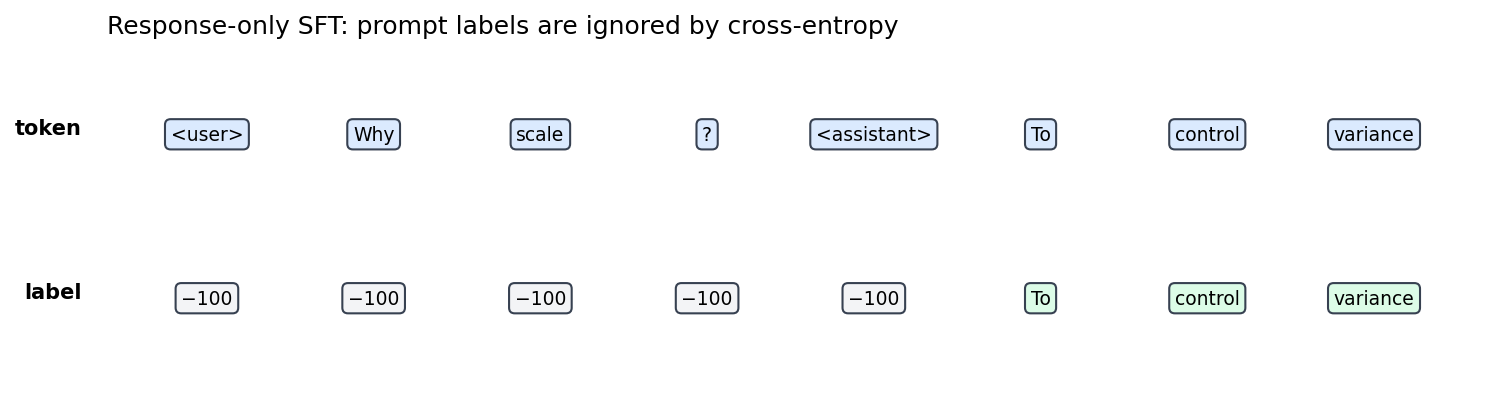

### Try it: Construct response-only labels

**What this cell shows**

Make the exact supervised objective inspectable.

**What goes in and comes out**

- Input IDs and labels are equal-length vectors
- ignored labels are `-100`.

**Follow the calculation**

1. Concatenate prompt and answer IDs, mask the prompt span, preserve answer IDs, and count active positions.

**Before you run the cell**

How many positions contribute to loss in the toy sequence? Write down the expected value, shape, or ordering before running the cell.

In [ ]:
from transformers import AutoTokenizer
from course_helpers import (
    CLASSROOM_MODEL, CLASSROOM_REVISION,
    build_final_answer_labels, active_label_fraction,
)

tokenizer = AutoTokenizer.from_pretrained(CLASSROOM_MODEL, revision=CLASSROOM_REVISION)
messages = conversation["messages"]
rendered = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
example = build_final_answer_labels(messages, tokenizer, max_length=512)

active_positions = [i for i, label in enumerate(example["labels"]) if label != -100]
print(rendered[:500])
print("token count:", len(example["input_ids"]))
print("first active label position:", active_positions[0])
print("active-label fraction:", round(active_label_fraction(example["labels"]), 3))
print("decoded target:", tokenizer.decode([x for x in example["labels"] if x != -100])[:300])

**What you should see**

Only answer positions contribute; the model still reads prompt IDs as context.

**If your result looks different**

Masking input IDs instead of labels removes context and teaches a different task.

Before moving on, compare the output with your prediction. If they differ, use the data description and tensor shapes above to find the first unexpected step.

## Learn and test: audit length before choosing truncation

A fixed `max_length` is a data decision, not merely a speed setting. We tokenize real records first and ask how often a limit would remove tokens. The final-answer helper keeps the end of an overlong conversation, but that may discard essential user context; such examples need filtering, summarization, or a larger limit rather than silent acceptance.

### Try it: measure the actual classroom distribution

**Before running:** predict whether the median or the maximum should determine a safe limit. Then check the number of supervised answer tokens after truncation, not only total sequence length.

**Inputs and outputs:** The named Python objects enter this step; the printed values, token counts, tensor shapes, or saved files are the observations to check.

In [ ]:
sample = train_rows[:200]
lengths = [
    len(tokenizer.apply_chat_template(
        row["messages"], tokenize=True, add_generation_prompt=False
    )["input_ids"])
    for row in sample
]
sorted_lengths = sorted(lengths)
for percentile in (50, 90, 95, 100):
    position = int((percentile / 100) * len(sorted_lengths))
    index = min(len(sorted_lengths) - 1, position)
    print(f"p{percentile}:", sorted_lengths[index])
count = sum(length > 512 for length in lengths)
print("examples above 512:", count, "of", len(lengths))

The maximum reveals rare expensive cases, while percentiles show how much of the dataset a limit affects. If many examples exceed 512 tokens, do not quietly truncate and report the original row count as if every answer remained intact. Record the policy and the post-filter count.

## Learn and test: estimate the memory required for full fine-tuning

Full fine-tuning updates every model parameter. The model weights are therefore only the first part of the memory budget. A common mixed-precision AdamW estimate assigns the following persistent storage to each trainable parameter:

| Stored value | Bytes per parameter | Why it is present |
|---|---:|---|
| BF16 model weight | 2 | Used by the forward and backward passes |
| BF16 gradient | 2 | Stores the derivative computed by backpropagation |
| FP32 master weight | 4 | Keeps a higher-precision copy for stable optimizer updates |
| Two FP32 Adam moments | 8 | Adam keeps a first and second running moment, each using 4 bytes |

Adding these terms gives `2 + 2 + 4 + 8 = 16 bytes` per trainable parameter. For a model with $P$ parameters, the simplified persistent-memory estimate is therefore

\[
M_{\text{persistent}} \approx 16P\ \text{bytes}.
\]

This is a planning estimate, not a universal law. An implementation may omit the FP32 master copy or use different optimizer states. The estimate excludes activations, temporary buffers, CUDA context, and allocator fragmentation. Activation memory varies with batch size, sequence length, architecture, attention kernels, and gradient checkpointing.

In this lecture, you will **estimate** the full-tuning baseline rather than run a full 1.5B-parameter update. The baseline gives you a concrete comparison for LoRA and QLoRA in Lecture 03.

### Where the persistent memory goes

The figure separates storage that exists once per trainable parameter from activations that grow with the input batch.

**Check your understanding:** which allocations scale with $P$, and which omitted allocation changes when you increase batch size or sequence length?

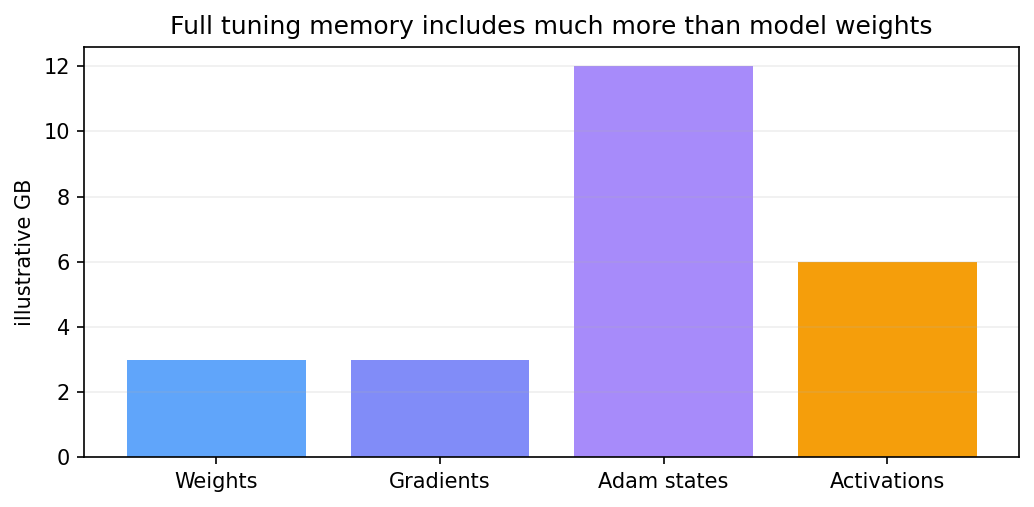

### Work a small example before writing code

Suppose a model has 100 million trainable parameters. Its BF16 weights require

\[
100{,}000{,}000 \times 2 \div 2^{30} \approx 0.19\ \text{GiB}.
\]

Gradients require another 0.19 GiB, FP32 master weights about 0.37 GiB, and Adam moments about 0.75 GiB. The persistent subtotal is about 1.49 GiB before storing activations.

### Try it: implement the estimate

**Why this code is needed:** it applies the same byte accounting to models of different sizes without hiding the assumptions.

**Inputs and outputs:** `parameter_count` is one positive integer. The function returns a dictionary whose values are GiB estimates. There are no batch or sequence tensors in this calculation.

**Key lines:** `bytes_per_parameter` makes every assumption visible. Multiplying by `parameter_count` converts a per-parameter cost to bytes; dividing by `2**30` converts bytes to GiB.

**Before running:** predict the largest row and estimate whether the 1.5B model's persistent subtotal is below or above 20 GiB.

In [ ]:
def full_finetuning_memory_estimate(parameter_count):
    if parameter_count <= 0:
        raise ValueError("parameter_count must be positive")
    bytes_per_parameter = {
        "BF16 weights": 2,
        "BF16 gradients": 2,
        "FP32 master weights": 4,
        "FP32 Adam moments": 8,  # two moments × 4 bytes
    }
    return {
        name: parameter_count * byte_count / 2**30
        for name, byte_count in bytes_per_parameter.items()
    }

model_sizes = {
    "SmolLM2 classroom": 134_515_008,
    "Qwen2.5 extension": 1_543_714_304,
}
for model_name, parameters in model_sizes.items():
    estimate = full_finetuning_memory_estimate(parameters)
    print()
    print(model_name)
    for allocation, gib in estimate.items():
        print(f"  {allocation:20s} {gib:6.2f} GiB")
    print("  persistent subtotal  ", f"{sum(estimate.values()):6.2f} GiB")

**What the result means:** SmolLM2 has a persistent subtotal of about 2.00 GiB, while the 1.5B model is about 23.00 GiB under these assumptions. Adam moments are the largest listed allocation because they store two FP32 values per parameter.

A 24 GiB GPU is therefore not guaranteed to fit full tuning of the 1.5B model: the 23 GiB subtotal leaves almost no room for activations and runtime overhead. Conversely, do not report 23 GiB as measured peak memory. To measure a real run, reset PyTorch's peak-memory counter, execute a representative training step, synchronize CUDA, and read the peak allocated and reserved memory.

The maintained helper in `course_helpers.py` uses the same formula. The module avoids repetition; the assumptions remain visible here where you first use it.

## A realistic failure—and what it teaches us

Truncating from the wrong end, adding special tokens twice, packing without boundary-aware masks, and padding with an active target can all yield a finite but meaningless loss. Full tuning also needs more than BF16 weight memory: gradients, optimizer states, activations, and temporary buffers matter. These checks precede Trainer construction because a fast run on corrupted labels is still a failed experiment.

**Debugging habit:** find the first expectation that failed—data
identity, shape, normalization, causality, optimization, retrieval,
grounding, or authorization. Then write the smallest check that
separates that problem from the nearby possibilities.

## Practice checkpoint

Construct labels where only the assistant response contributes to loss, and assert tree-level split isolation.

Before editing code, write a prediction and name the invariant that should remain true. Record the observed result in this notebook, compare it with your prediction, and write one sentence explaining any discrepancy.

## Instructor check-in

After running the practice checkpoint, send a short email from your Clemson account. Include your full name, Clemson email, observed evidence, and interpretation.

**Evidence to include:** Report your tree-overlap result and active-label fraction, then explain why prompt tokens use the ignore index.

The final line is not only for problems. You may send a question **or** describe something that worked well or changed your understanding.

[📧 Send the checkpoint email](mailto:fanchem@clemson.edu?subject=Watt%20AI%20lesson%20check-in%20-%20Lesson%2002%20-%20Fine-tuning%20data%20and%20objective&body=Lesson%2002%20-%20Fine-tuning%20data%20and%20objective%0A%0AFull%20name%3A%0AClemson%20email%3A%0A%0AObserved%20evidence%3A%0A%0AWhat%20the%20evidence%20means%3A%0A%0AOne%20remaining%20question%20or%20one%20useful%20takeaway%3A)

If the button does not open your Clemson mail client, email [fanchem@clemson.edu](mailto:fanchem@clemson.edu) with the subject **Watt AI lesson check-in — Lesson 02 - Fine-tuning data and objective** and use the same fields above.

## Check your work

Expand the reference solution only after attempting the exercise.

In [ ]:
prompt_ids, answer_ids = [10, 11, 12], [20, 21]
labels = [-100] * len(prompt_ids) + answer_ids
assert all(x == -100 for x in labels[:len(prompt_ids)])
assert {"tree-a"}.isdisjoint({"tree-b"})
print(labels)

## Final concept map

Conversation trees → group-isolated splits → canonical messages → pinned chat rendering → IDs and assistant mask → truncation/packing audit → collated `B×T` input, attention, and label tensors → full-tuning memory baseline.

Return to the driving question: **How do we turn branching conversations into labels without leakage or training on the user's words?** Explain the answer without using library names. Then identify which new limitation motivates the next lecture.

## Homework

Audit the prepared OpenAssistant classroom set: tree isolation, chat rendering, active-label fraction, truncation, deduplication, and leakage checks.

The full assignment and rubric are in this course's `homework/` folder.
Attempt the work before opening the collapsed check-your-work cell above.

## Glossary

| Term | Meaning in this lesson |
|---|---|
| **conversation tree** | Related turns and branches sharing ancestors. |
| **split isolation** | Keeping a related group entirely in one split. |
| **assistant-only loss** | Cross-entropy evaluated only on assistant target tokens. |
| **packing** | Placing multiple short examples in one fixed-length sequence. |
| **active label** | A target ID not replaced by the ignore value. |
| **collator** | A function converting examples into a padded batch. |

A useful definition lets you predict behavior. Test yourself by giving one example and one non-example for every term rather than memorizing the wording.

## Sources and further study

The explanations, code, numeric examples, and figures in this notebook are course-original. These primary or official sources check terminology and provide a deeper path:

- [Hugging Face Chat Templates](https://huggingface.co/docs/transformers/chat_templating) — Official message-format and generation-prompt behavior.
- [TRL SFTTrainer](https://huggingface.co/docs/trl/sft_trainer) — Official SFT data, masking, packing, and trainer behavior.

- [Clemson CITI fine-tuning workshop](https://clemsonciti.github.io/rcde_workshops/llms_finetune/00-index.html) and [alternatives to fine-tuning](https://clemsonciti.github.io/rcde_workshops/llms_finetune/01-alternatives.html) — optional structural comparison and further reading; no workshop prose or images are copied.

- [SmolLM2-135M-Instruct model card](https://huggingface.co/HuggingFaceTB/SmolLM2-135M-Instruct) — pinned classroom artifact and license.
- [Bitsandbytes quantization](https://huggingface.co/docs/transformers/quantization/bitsandbytes) — official four-bit loading behavior.

Source role: conceptual or implementation verification. Accessed 2026-08-18. External images are not hotlinked; redistributed assets require the course license manifest.